# Phase Shift Keying



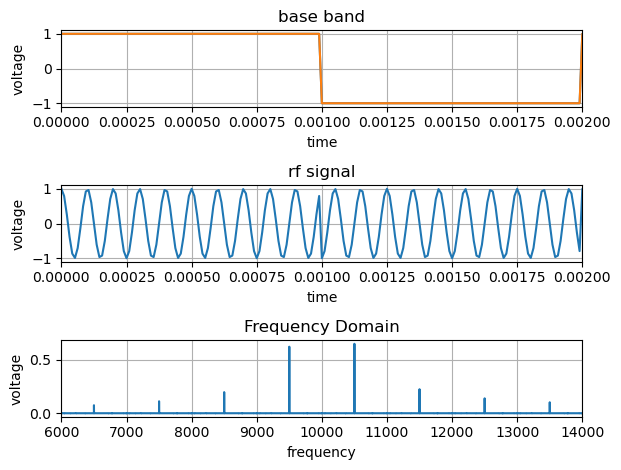

In [8]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from IPython.display import Audio

# Generate time vector
fs = 96000  # sample rate
Ts = 1/fs  # time step
Tmax = 2 # total simulation time
t = np.arange(0, Tmax, Ts)  # time vector start / end / step


# baseband square wave 500 Hz -> 1000 bits per second
fb1 = 500  # Hz 
A1 = 1  # Amplitude in V 
ub = A1 * signal.square(2 * np.pi * fb1 * t) # bipolar +/-1 


# carrier
Uc = 1 # V
fc = 10000 # Hz
uc = Uc * np.cos(2 * np.pi * fc * t)

# carrier keying
# u_am = uc * ub 
u_bpsk = uc * ub


# Calculate Frequency Spectrum
# with Fast Fourier Transformation (FFT)
n = len(u_bpsk)  # number of samples
F = np.fft.fft(u_bpsk)[:n//2]  # complex fourier coefficient (= amplitude) at each pos. frequency
f = np.fft.fftfreq(n, Ts)[:n//2] # n Elemente mit Abstand Ts (pos. Frequenzen)
volt = 2/n * np.abs(F)  # absolute value of amplitude

# calculate peaks in spectrum
# peakfreq, _ = signal.find_peaks(volt, height=1e-3)
# print(peakfreq * fs/n) # scale frequencies
# print(volt[peakfreq]) # amplitudes

# Plot Time Domain (Zeitbereichsdarstellung)
plt.subplot(3, 1, 1)  # 2 rows, 1 column, 1st row
plt.plot(t, ub, t, ub)
plt.grid(True)
plt.xlim(0, 0.002)
plt.title('base band') 
plt.xlabel('time')
plt.ylabel('voltage')

plt.subplot(3, 1, 2) 
plt.plot(t, u_bpsk)
plt.grid(True)
plt.xlim(0, 0.002)
plt.title('rf signal') 
plt.xlabel('time')
plt.ylabel('voltage')

# Plot Frequency Domain (Frequenzbereichsdarstellung)
plt.subplot(3, 1, 3)  
plt.plot(f, volt)
plt.grid(True)
#plt.axis([5000, 15000, 0, 2.5])
plt.xlim(6000, 14000)
plt.title('Frequency Domain')  
plt.xlabel('frequency')
plt.ylabel('voltage')

plt.tight_layout()
plt.show()

